# Monte Carlo Sample Visualization and Analysis

This notebook analyzes and visualizes Monte Carlo samples generated by C++ particle distribution generators. It provides comprehensive statistical analysis, histograms, and 2D density plots for four different sampling methods.

## Load Data into DataFrames

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.constrained_layout.use'] = True

print("Libraries imported successfully.")
workspace_root = "./"
# workspace_root = "../cpp/"

Libraries imported successfully.


In [2]:
# Load velocity distribution data

df_general_velocity = pd.read_csv(workspace_root+'samples_general_velocity.txt', delim_whitespace=True,
                                    names=['vx', 'vy', 'vz'], dtype=np.float64)

# Load position distribution data
df_general_position = pd.read_csv(workspace_root+'samples_general_position.txt', delim_whitespace=True,
                                    names=['x', 'y', 'z'], dtype=np.float64)

print("Data loaded successfully.")
print(f"\nGeneral Velocity Generator:\n  Shape: {df_general_velocity.shape}\n  First 5 rows:\n{df_general_velocity.head()}")
print(f"\nGeneral Position Generator:\n  Shape: {df_general_position.shape}\n  First 5 rows:\n{df_general_position.head()}")

Data loaded successfully.

General Velocity Generator:
  Shape: (1000000, 3)
  First 5 rows:
         vx        vy        vz
0  0.770642 -0.514943 -0.137856
1  1.146775 -0.025564 -0.734401
2 -2.163667 -1.267196 -0.213390
3 -0.089937 -0.179745  0.293256
4  0.571778  0.634175 -0.030779

General Position Generator:
  Shape: (1000000, 3)
  First 5 rows:
          x         y         z
0 -1.384282  1.134110 -0.408422
1 -0.119943 -0.976430 -0.740471
2  0.003489  0.000524 -1.145123
3  1.189629 -0.445225  0.007361
4 -0.613164 -0.973043 -0.915781


## Compute Derived Quantities for Velocity Datasets

In [3]:
# Physical parameters
mass = 1.0  # Particle mass (normalized)

# Function to compute derived quantities for velocity data
def compute_velocity_quantities(df):
    df = df.copy()
    df['v_perp'] = np.sqrt(df['vx']**2 + df['vy']**2)  # Perpendicular velocity magnitude
    df['speed'] = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)  # Total speed
    df['energy'] = 0.5 * mass * df['speed']**2  # Kinetic energy
    return df

# Compute derived quantities
df_general_velocity = compute_velocity_quantities(df_general_velocity)

print("Derived velocity quantities computed.")

Derived velocity quantities computed.


## Compute Derived Quantities for Position Dataset

In [4]:
# Compute radial coordinate for position data
df_general_position['radius'] = np.sqrt(df_general_position['x']**2 + 
                                          df_general_position['y']**2 + 
                                          df_general_position['z']**2)

print("Derived position quantities computed.")
print(f"\nPosition data with radius:\n  Columns: {list(df_general_position.columns)}\n  First 3 rows:\n{df_general_position.head(3)}")

Derived position quantities computed.

Position data with radius:
  Columns: ['x', 'y', 'z', 'radius']
  First 3 rows:
          x         y         z    radius
0 -1.384282  1.134110 -0.408422  1.835553
1 -0.119943 -0.976430 -0.740471  1.231300
2  0.003489  0.000524 -1.145123  1.145128


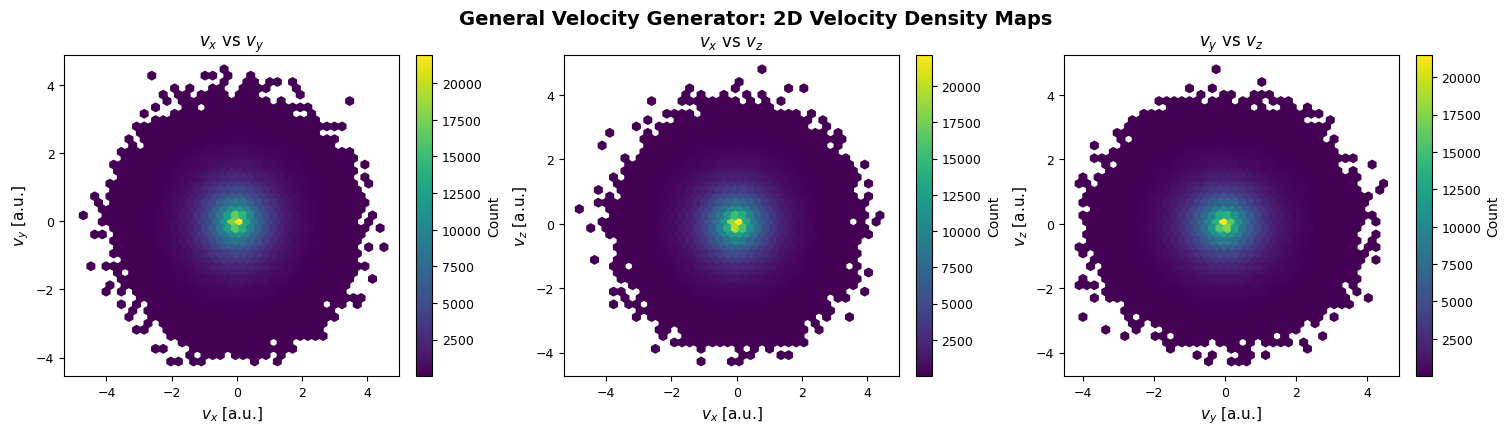

General velocity 2D density maps plotted.


In [5]:
# General velocity generator: 2D density plots for velocity space
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('General Velocity Generator: 2D Velocity Density Maps', fontsize=14, fontweight='bold', y=1.05)

# vx vs vy
hb1 = axes[0].hexbin(df_general_velocity['vx'], df_general_velocity['vy'], gridsize=40, cmap='viridis', mincnt=1)
axes[0].set_xlabel('$v_x$ [a.u.]')
axes[0].set_ylabel('$v_y$ [a.u.]')
axes[0].set_title('$v_x$ vs $v_y$')
cb1 = plt.colorbar(hb1, ax=axes[0])
cb1.set_label('Count', fontsize=10)

# vx vs vz
hb2 = axes[1].hexbin(df_general_velocity['vx'], df_general_velocity['vz'], gridsize=40, cmap='viridis', mincnt=1)
axes[1].set_xlabel('$v_x$ [a.u.]')
axes[1].set_ylabel('$v_z$ [a.u.]')
axes[1].set_title('$v_x$ vs $v_z$')
cb2 = plt.colorbar(hb2, ax=axes[1])
cb2.set_label('Count', fontsize=10)

# vy vs vz
hb3 = axes[2].hexbin(df_general_velocity['vy'], df_general_velocity['vz'], gridsize=40, cmap='viridis', mincnt=1)
axes[2].set_xlabel('$v_y$ [a.u.]')
axes[2].set_ylabel('$v_z$ [a.u.]')
axes[2].set_title('$v_y$ vs $v_z$')
cb3 = plt.colorbar(hb3, ax=axes[2])
cb3.set_label('Count', fontsize=10)

plt.show()

print("General velocity 2D density maps plotted.")

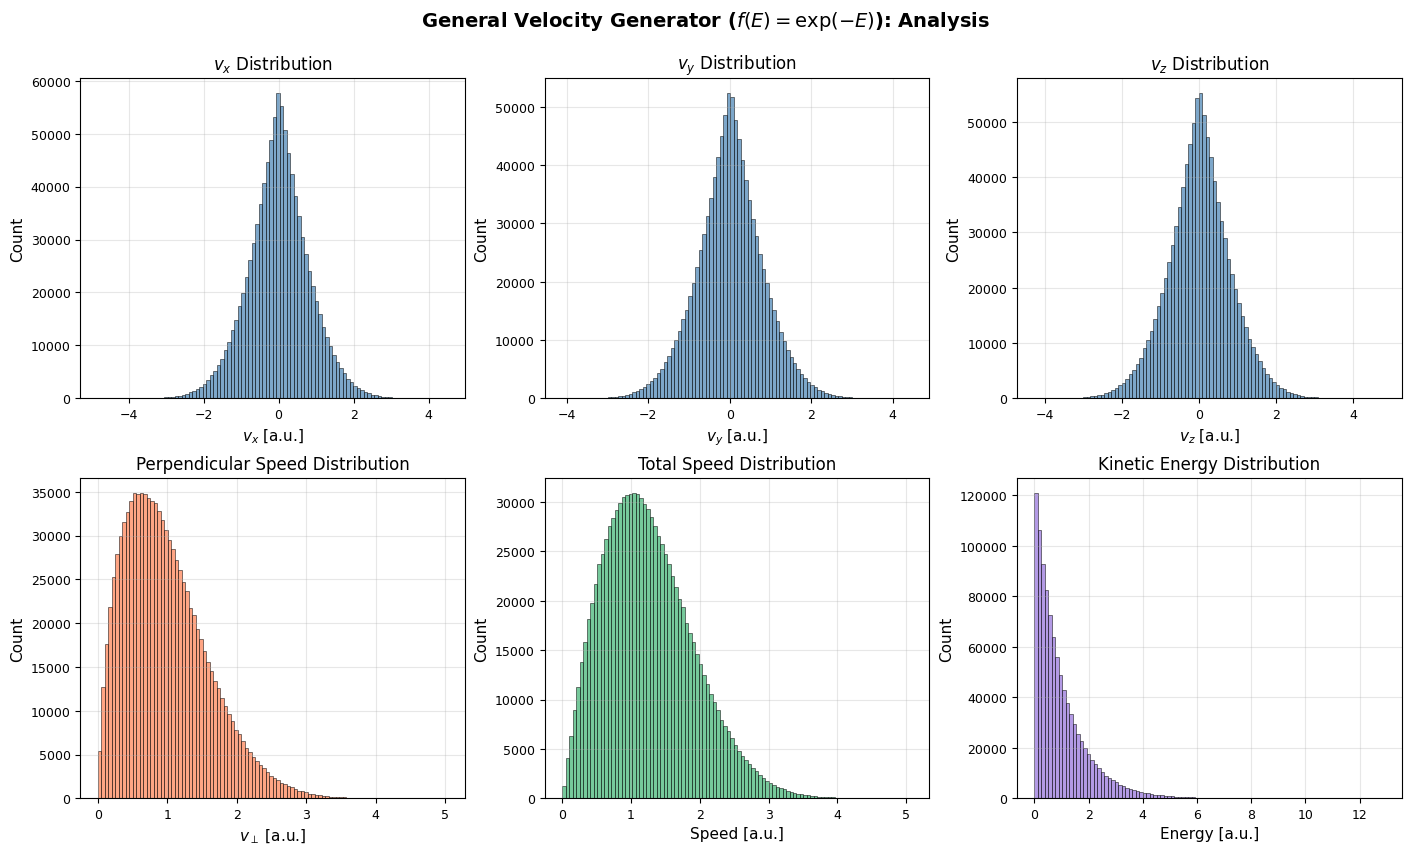

General velocity histograms plotted.


In [6]:
# General velocity generator: Histograms of velocity components and derived quantities
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('General Velocity Generator ($f(E) = \\exp(-E)$): Analysis', fontsize=14, fontweight='bold', y=1.05)

# Velocity components
axes[0, 0].hist(df_general_velocity['vx'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 0].set_xlabel('$v_x$ [a.u.]')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('$v_x$ Distribution')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df_general_velocity['vy'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('$v_y$ [a.u.]')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('$v_y$ Distribution')
axes[0, 1].grid(alpha=0.3)

axes[0, 2].hist(df_general_velocity['vz'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 2].set_xlabel('$v_z$ [a.u.]')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('$v_z$ Distribution')
axes[0, 2].grid(alpha=0.3)

# Derived quantities
axes[1, 0].hist(df_general_velocity['v_perp'], bins=100, color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('$v_{\\perp}$ [a.u.]')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Perpendicular Speed Distribution')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(df_general_velocity['speed'], bins=100, color='mediumseagreen', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Speed [a.u.]')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Total Speed Distribution')
axes[1, 1].grid(alpha=0.3)

axes[1, 2].hist(df_general_velocity['energy'], bins=100, color='mediumpurple', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 2].set_xlabel('Energy [a.u.]')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Kinetic Energy Distribution')
axes[1, 2].grid(alpha=0.3)

plt.show()

print("General velocity histograms plotted.")

## General Position Generator Analysis

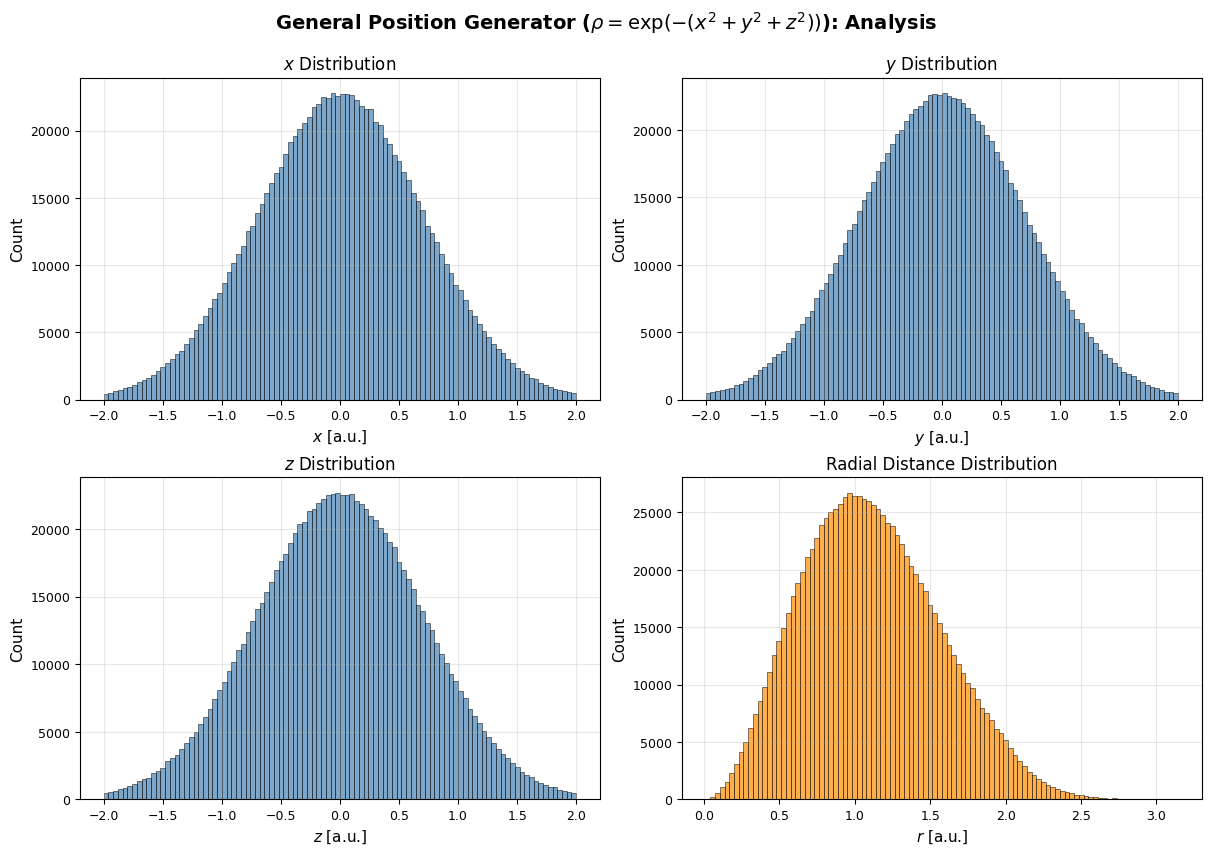

General position histograms plotted.


In [7]:
# General position generator: Histograms of position components and radius
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('General Position Generator ($\\rho = \\exp(-(x^2+y^2+z^2))$): Analysis', fontsize=14, fontweight='bold', y=1.05)

# Position components
axes[0, 0].hist(df_general_position['x'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 0].set_xlabel('$x$ [a.u.]')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('$x$ Distribution')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df_general_position['y'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('$y$ [a.u.]')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('$y$ Distribution')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(df_general_position['z'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('$z$ [a.u.]')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('$z$ Distribution')
axes[1, 0].grid(alpha=0.3)

# Radial distribution
axes[1, 1].hist(df_general_position['radius'], bins=100, color='darkorange', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('$r$ [a.u.]')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Radial Distance Distribution')
axes[1, 1].grid(alpha=0.3)

plt.show()

print("General position histograms plotted.")

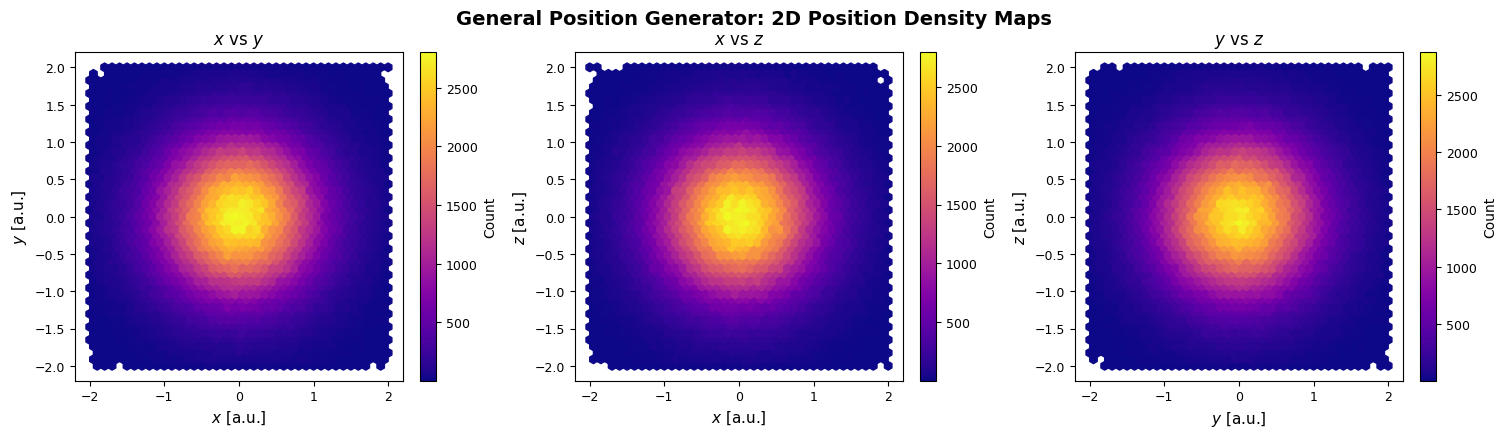

General position 2D density maps plotted.


In [8]:
# General position generator: 2D density plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('General Position Generator: 2D Position Density Maps', fontsize=14, fontweight='bold', y=1.05)

# x vs y
hb1 = axes[0].hexbin(df_general_position['x'], df_general_position['y'], gridsize=40, cmap='plasma', mincnt=1)
axes[0].set_xlabel('$x$ [a.u.]')
axes[0].set_ylabel('$y$ [a.u.]')
axes[0].set_title('$x$ vs $y$')
cb1 = plt.colorbar(hb1, ax=axes[0])
cb1.set_label('Count', fontsize=10)
axes[0].set_aspect('equal')

# x vs z
hb2 = axes[1].hexbin(df_general_position['x'], df_general_position['z'], gridsize=40, cmap='plasma', mincnt=1)
axes[1].set_xlabel('$x$ [a.u.]')
axes[1].set_ylabel('$z$ [a.u.]')
axes[1].set_title('$x$ vs $z$')
cb2 = plt.colorbar(hb2, ax=axes[1])
cb2.set_label('Count', fontsize=10)
axes[1].set_aspect('equal')

# y vs z
hb3 = axes[2].hexbin(df_general_position['y'], df_general_position['z'], gridsize=40, cmap='plasma', mincnt=1)
axes[2].set_xlabel('$y$ [a.u.]')
axes[2].set_ylabel('$z$ [a.u.]')
axes[2].set_title('$y$ vs $z$')
cb3 = plt.colorbar(hb3, ax=axes[2])
cb3.set_label('Count', fontsize=10)
axes[2].set_aspect('equal')

plt.show()

print("General position 2D density maps plotted.")

## Comparison of Anisotropic Velocity Distributions

## 3D Scatter Plot Subsampling

In [10]:
from mpl_toolkits.mplot3d import Axes3D

# Subsampling function: select max 5000 points for visualization
def subsample_data(data, max_points=5000):
    n_samples = len(data)
    if n_samples > max_points:
        indices = np.random.choice(n_samples, max_points, replace=False)
        return data.iloc[indices]
    else:
        return data

# Subsample all datasets
df_general_velocity_sub = subsample_data(df_general_velocity)
df_general_position_sub = subsample_data(df_general_position)

print(f"Subsampled dataset sizes:")
print(f"  General Velocity: {len(df_general_velocity_sub)} points")
print(f"  General Position: {len(df_general_position_sub)} points")

Subsampled dataset sizes:
  General Velocity: 5000 points
  General Position: 5000 points


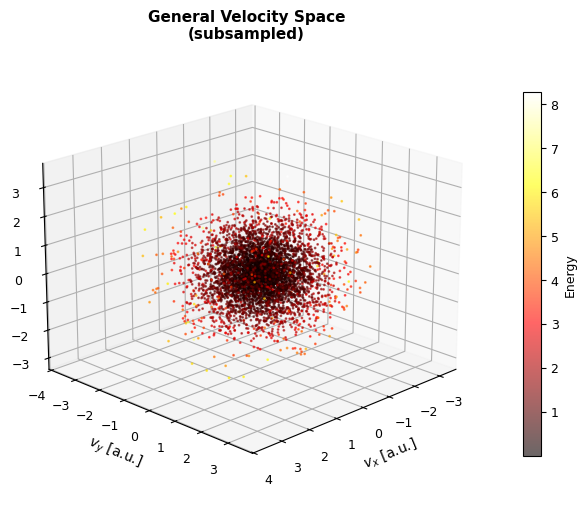

Velocity space 3D scatter plots displayed.


In [11]:
# 3D visualization for velocity distributions
fig = plt.figure(figsize=(16, 5))

# BiKappa 3D scatter
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(df_general_velocity_sub['vx'], df_general_velocity_sub['vy'], df_general_velocity_sub['vz'],
                        c=df_general_velocity_sub['energy'], cmap='hot', s=1, alpha=0.6)
ax1.set_xlabel('$v_x$ [a.u.]', fontsize=10)
ax1.set_ylabel('$v_y$ [a.u.]', fontsize=10)
ax1.set_zlabel('$v_z$ [a.u.]', fontsize=10)
ax1.set_title('General Velocity Space\n(subsampled)', fontsize=11, fontweight='bold')
ax1.view_init(elev=20, azim=45)
cb1 = plt.colorbar(scatter1, ax=ax1, pad=0.1, shrink=0.8)
cb1.set_label('Energy', fontsize=9)

# plt.suptitle('3D Velocity Space Visualization (Energy-Colored)', fontsize=14, fontweight='bold', y=1.05)
plt.show()

print("Velocity space 3D scatter plots displayed.")

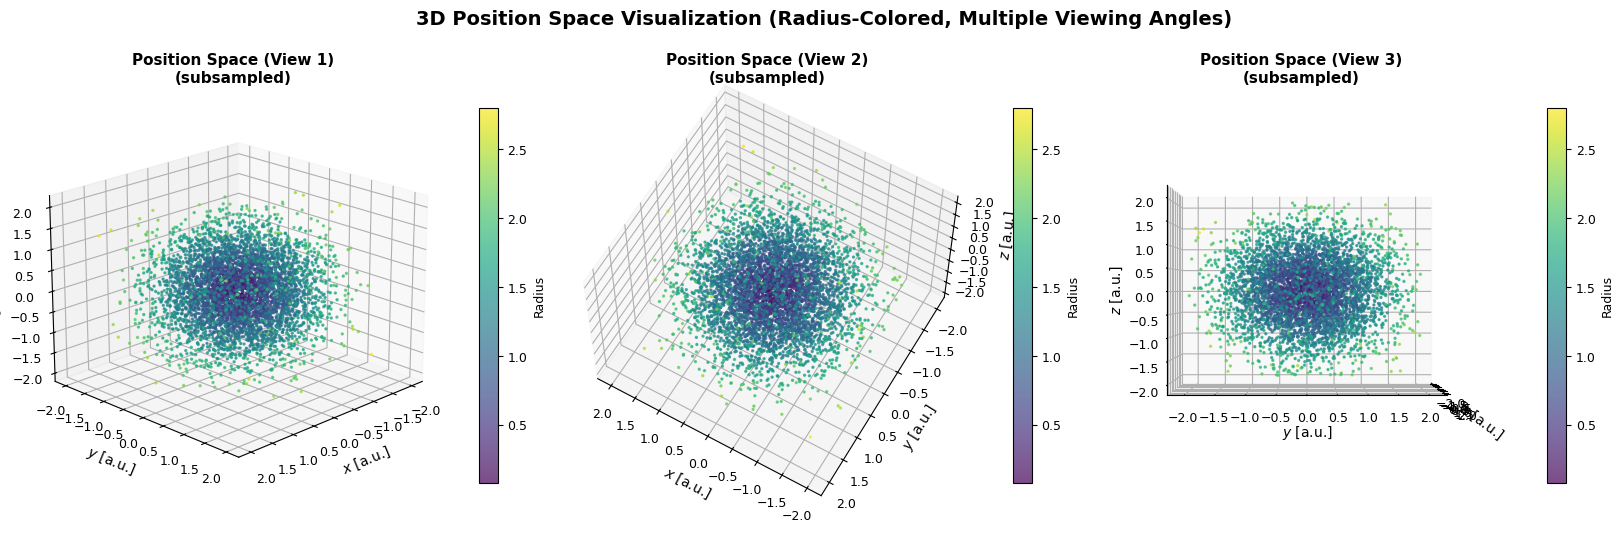

Position space 3D scatter plots displayed with multiple viewing angles.


In [12]:
# 3D visualization for position distribution
fig = plt.figure(figsize=(16, 5))

# General Position 3D scatter - view 1
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(df_general_position_sub['x'], df_general_position_sub['y'], df_general_position_sub['z'],
                        c=df_general_position_sub['radius'], cmap='viridis', s=2, alpha=0.7)
ax1.set_xlabel('$x$ [a.u.]', fontsize=10)
ax1.set_ylabel('$y$ [a.u.]', fontsize=10)
ax1.set_zlabel('$z$ [a.u.]', fontsize=10)
ax1.set_title('Position Space (View 1)\n(subsampled)', fontsize=11, fontweight='bold')
ax1.view_init(elev=20, azim=45)
cb1 = plt.colorbar(scatter1, ax=ax1, pad=0.1, shrink=0.8)
cb1.set_label('Radius', fontsize=9)

# General Position 3D scatter - view 2
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(df_general_position_sub['x'], df_general_position_sub['y'], df_general_position_sub['z'],
                        c=df_general_position_sub['radius'], cmap='viridis', s=2, alpha=0.7)
ax2.set_xlabel('$x$ [a.u.]', fontsize=10)
ax2.set_ylabel('$y$ [a.u.]', fontsize=10)
ax2.set_zlabel('$z$ [a.u.]', fontsize=10)
ax2.set_title('Position Space (View 2)\n(subsampled)', fontsize=11, fontweight='bold')
ax2.view_init(elev=60, azim=120)
cb2 = plt.colorbar(scatter2, ax=ax2, pad=0.1, shrink=0.8)
cb2.set_label('Radius', fontsize=9)

# General Position 3D scatter - view 3
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(df_general_position_sub['x'], df_general_position_sub['y'], df_general_position_sub['z'],
                        c=df_general_position_sub['radius'], cmap='viridis', s=2, alpha=0.7)
ax3.set_xlabel('$x$ [a.u.]', fontsize=10)
ax3.set_ylabel('$y$ [a.u.]', fontsize=10)
ax3.set_zlabel('$z$ [a.u.]', fontsize=10)
ax3.set_title('Position Space (View 3)\n(subsampled)', fontsize=11, fontweight='bold')
ax3.view_init(elev=0, azim=0)
cb3 = plt.colorbar(scatter3, ax=ax3, pad=0.1, shrink=0.8)
cb3.set_label('Radius', fontsize=9)

plt.suptitle('3D Position Space Visualization (Radius-Colored, Multiple Viewing Angles)', fontsize=14, fontweight='bold', y=1.05)
plt.show()

print("Position space 3D scatter plots displayed with multiple viewing angles.")

### Reference function: $\rho(x,y)=1+\sin(x)\sin(y)$

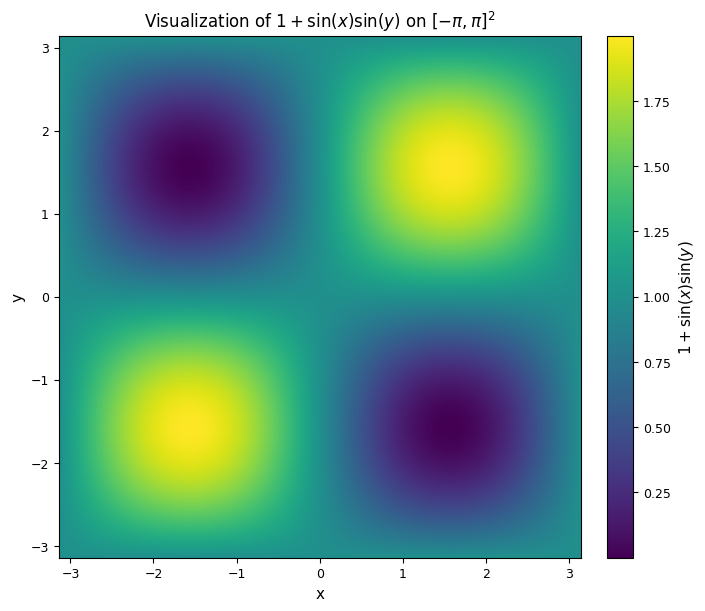

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Grid on [-pi, pi] x [-pi, pi]
n = 400
x = np.linspace(-np.pi, np.pi, n)
y = np.linspace(-np.pi, np.pi, n)
X, Y = np.meshgrid(x, y)

# Function
Z = 1 + np.sin(X) * np.sin(Y)

# Plot
plt.figure(figsize=(7, 6))
plt.imshow(
    Z,
    extent=[-np.pi, np.pi, -np.pi, np.pi],
    origin="lower",
    aspect="equal"
)
plt.colorbar(label=r"$1+\sin(x)\sin(y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Visualization of $1+\sin(x)\sin(y)$ on $[-\pi,\pi]^2$")
plt.show()
